# UAS Kecerdasan Buatan

## Klasifikasi Kualitas Air Layak Konsumsi Menggunakan Decision Tree dan KNN

Notebook ini berisi proses lengkap mulai dari load dataset, data understanding, EDA, data preparation, modeling, hingga evaluation.


## 1. Import Library


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import warnings
warnings.filterwarnings('ignore')


## 2. Load Dataset


In [34]:
# Load dataset
file_path = 'data/dataset/waterquality.csv'
df = pd.read_csv(file_path)

# Menampilkan 5 data pertama
df.head()


,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1


In [4]:
# Ukuran dataset
print('Jumlah baris dan kolom:', df.shape)
print('Daftar kolom:')
print(df.columns.tolist())


Jumlah baris dan kolom: (7999, 21)
Daftar kolom:
['aluminium', 'ammonia', 'arsenic', 'barium', 'cadmium', 'chloramine', 'chromium', 'copper', 'flouride', 'bacteria', 'viruses', 'lead', 'nitrates', 'nitrites', 'mercury', 'perchlorate', 'radium', 'selenium', 'silver', 'uranium', 'is_safe']


## 3. Data Understanding


In [5]:
# Informasi tipe data
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7999 entries, 0 to 7998
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7999 non-null   float64
 1   ammonia      7999 non-null   object 
 2   arsenic      7999 non-null   float64
 3   barium       7999 non-null   float64
 4   cadmium      7999 non-null   float64
 5   chloramine   7999 non-null   float64
 6   chromium     7999 non-null   float64
 7   copper       7999 non-null   float64
 8   flouride     7999 non-null   float64
 9   bacteria     7999 non-null   float64
 10  viruses      7999 non-null   float64
 11  lead         7999 non-null   float64
 12  nitrates     7999 non-null   float64
 13  nitrites     7999 non-null   float64
 14  mercury      7999 non-null   float64
 15  perchlorate  7999 non-null   float64
 16  radium       7999 non-null   float64
 17  selenium     7999 non-null   float64
 18  silver       7999 non-null   float64
 19  uraniu

In [6]:
# Statistik deskriptif awal
print(df.describe(include='all'))


          aluminium ammonia      arsenic       barium      cadmium  \
count   7999.000000    7999  7999.000000  7999.000000  7999.000000   
unique          NaN    2564          NaN          NaN          NaN   
top             NaN    0.17          NaN          NaN          NaN   
freq            NaN      13          NaN          NaN          NaN   
mean       0.666158     NaN     0.161445     1.567715     0.042806   
std        1.265145     NaN     0.252590     1.216091     0.036049   
min        0.000000     NaN     0.000000     0.000000     0.000000   
25%        0.040000     NaN     0.030000     0.560000     0.008000   
50%        0.070000     NaN     0.050000     1.190000     0.040000   
75%        0.280000     NaN     0.100000     2.480000     0.070000   
max        5.050000     NaN     1.050000     4.940000     0.130000   

         chloramine     chromium       copper     flouride     bacteria  ...  \
count   7999.000000  7999.000000  7999.000000  7999.000000  7999.000000  ...   

In [7]:
# Cek nilai unik pada target
print(df['is_safe'].value_counts(dropna=False))


is_safe
0        7084
1         912
#NUM!       3
Name: count, dtype: int64


In [8]:
# Cek nilai error #NUM! pada setiap kolom
for col in df.columns:
    jumlah_error = (df[col].astype(str) == '#NUM!').sum()
    if jumlah_error > 0:
        print(col, jumlah_error)


ammonia 3
is_safe 3


## 4. Data Preparation

Pada dataset terdapat nilai `#NUM!` pada kolom `ammonia` dan `is_safe`. Nilai tersebut akan diganti menjadi `NaN`, lalu baris yang mengandung nilai kosong akan dihapus. Setelah itu seluruh kolom dikonversi menjadi numerik.


In [9]:
# Mengganti #NUM! menjadi NaN
df_clean = df.replace('#NUM!', np.nan)

# Mengubah semua kolom menjadi numerik
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Mengecek jumlah missing value
print(df_clean.isna().sum())


aluminium      0
ammonia        3
arsenic        0
barium         0
cadmium        0
chloramine     0
chromium       0
copper         0
flouride       0
bacteria       0
viruses        0
lead           0
nitrates       0
nitrites       0
mercury        0
perchlorate    0
radium         0
selenium       0
silver         0
uranium        0
is_safe        3
dtype: int64


In [10]:
# Menghapus data kosong dan duplikat
print('Jumlah data sebelum cleaning:', df_clean.shape)
print('Jumlah baris dengan missing value:', df_clean.isna().any(axis=1).sum())
print('Jumlah duplikat sebelum cleaning:', df_clean.duplicated().sum())

df_clean = df_clean.dropna()
df_clean = df_clean.drop_duplicates()

print('Jumlah data setelah cleaning:', df_clean.shape)
print('Jumlah duplikat setelah cleaning:', df_clean.duplicated().sum())


Jumlah data sebelum cleaning: (7999, 21)
Jumlah baris dengan missing value: 3
Jumlah duplikat sebelum cleaning: 0
Jumlah data setelah cleaning: (7996, 21)
Jumlah duplikat setelah cleaning: 0


In [11]:
# Mengubah target menjadi integer
df_clean['is_safe'] = df_clean['is_safe'].astype(int)

# Cek distribusi target setelah cleaning
print(df_clean['is_safe'].value_counts())
print('Persentase target:')
print(df_clean['is_safe'].value_counts(normalize=True) * 100)


is_safe
0    7084
1     912
Name: count, dtype: int64
Persentase target:
is_safe
0    88.594297
1    11.405703
Name: proportion, dtype: float64


## 5. Exploratory Data Analysis (EDA)


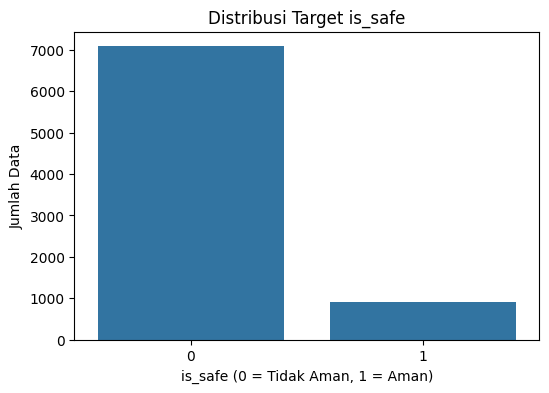

In [12]:
# Visualisasi distribusi target
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='is_safe')
plt.title('Distribusi Target is_safe')
plt.xlabel('is_safe (0 = Tidak Aman, 1 = Aman)')
plt.ylabel('Jumlah Data')
plt.show()


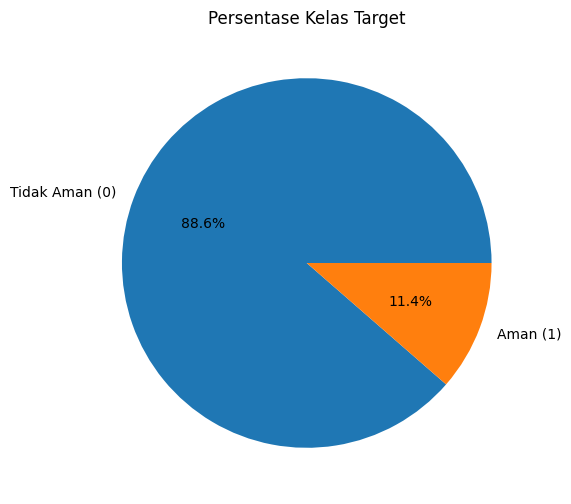

In [13]:
# Pie chart distribusi target
plt.figure(figsize=(6, 6))
df_clean['is_safe'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Tidak Aman (0)', 'Aman (1)']
)
plt.title('Persentase Kelas Target')
plt.ylabel('')
plt.show()


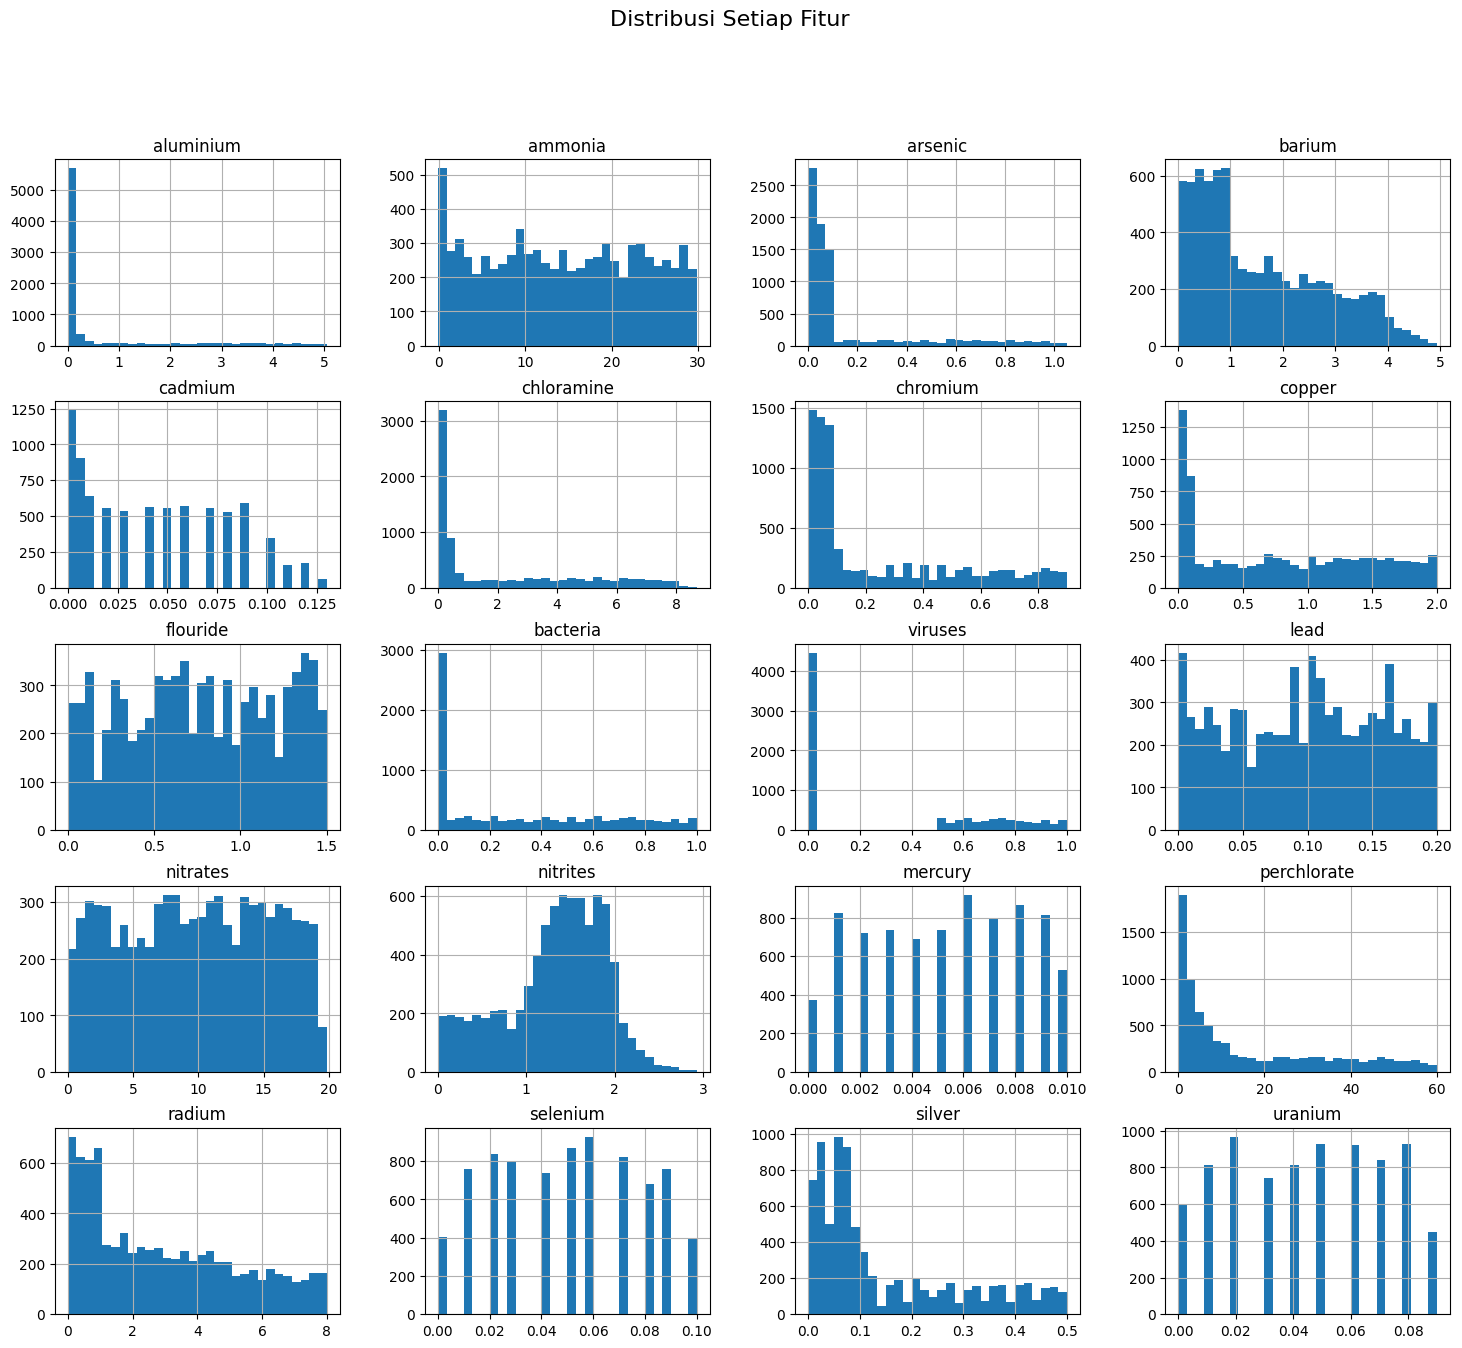

In [14]:
# Histogram setiap fitur
fitur = df_clean.drop(columns=['is_safe']).columns

df_clean[fitur].hist(figsize=(18, 15), bins=30)
plt.suptitle('Distribusi Setiap Fitur', fontsize=16)
plt.show()


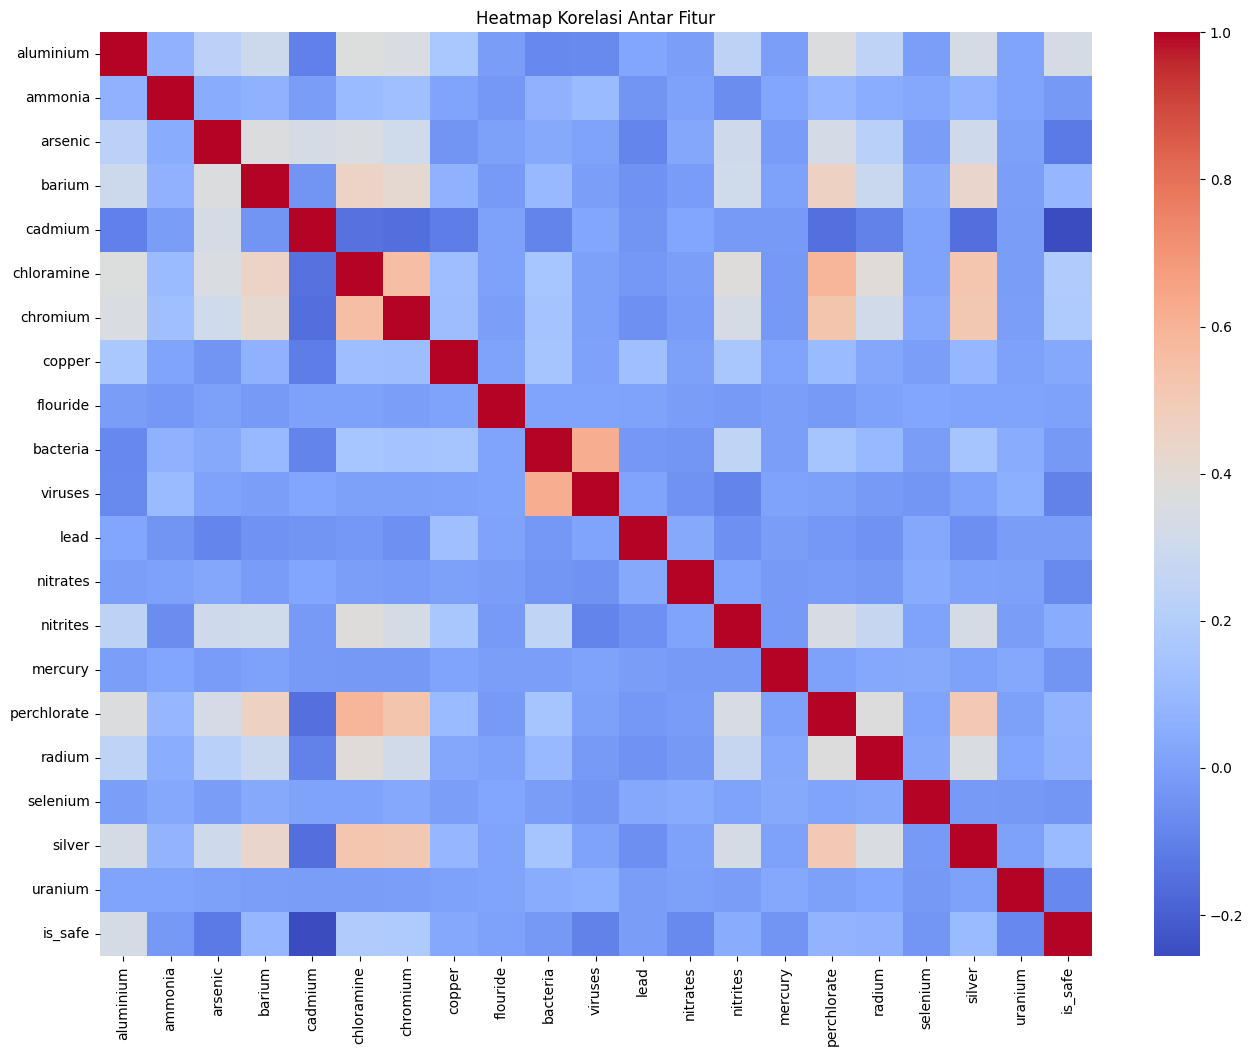

In [15]:
# Heatmap korelasi
plt.figure(figsize=(16, 12))
corr = df_clean.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()


In [16]:
# Korelasi fitur terhadap target
corr_target = df_clean.corr(numeric_only=True)['is_safe'].drop('is_safe').sort_values(key=abs, ascending=False)
print(corr_target)


aluminium      0.333974
cadmium       -0.256034
chloramine     0.186704
chromium       0.182306
arsenic       -0.123362
silver         0.102813
viruses       -0.097040
barium         0.090858
perchlorate    0.075735
uranium       -0.075619
nitrates      -0.072100
radium         0.064743
nitrites       0.046986
mercury       -0.036817
selenium      -0.030923
copper         0.029498
ammonia       -0.022919
bacteria      -0.022077
lead          -0.009970
flouride       0.006550
Name: is_safe, dtype: float64


## 6. Split Data Train-Test


In [18]:
# Memisahkan fitur dan target
X = df_clean.drop(columns=['is_safe'])
y = df_clean['is_safe']

# Split data 80:20 dengan stratify agar proporsi kelas tetap terjaga
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Jumlah data latih:', X_train.shape)
print('Jumlah data uji:', X_test.shape)
print('Distribusi target data latih:')
print(y_train.value_counts(normalize=True) * 100)
print('Distribusi target data uji:')
print(y_test.value_counts(normalize=True) * 100)


Jumlah data latih: (6396, 20)
Jumlah data uji: (1600, 20)
Distribusi target data latih:
is_safe
0    88.586617
1    11.413383
Name: proportion, dtype: float64
Distribusi target data uji:
is_safe
0    88.625
1    11.375
Name: proportion, dtype: float64


## 7. Modeling

Model yang digunakan:

1. Decision Tree Classifier
2. K-Nearest Neighbor dengan StandardScaler


In [19]:
# Model 1: Decision Tree
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

# Prediksi Decision Tree
y_pred_dt = model_dt.predict(X_test)


In [20]:
# Model 2: KNN dengan StandardScaler
model_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

model_knn.fit(X_train, y_train)

# Prediksi KNN
y_pred_knn = model_knn.predict(X_test)


## 8. Evaluation


In [22]:
# Fungsi evaluasi model
def evaluasi_model(nama_model, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print('Model:', nama_model)
    print('Accuracy :', round(acc, 4))
    print('Precision:', round(prec, 4))
    print('Recall   :', round(rec, 4))
    print('F1-score :', round(f1, 4))
    print('Confusion Matrix:')
    print(cm)
    print('Classification Report:')
    print(classification_report(y_true, y_pred, zero_division=0))

    return {
        'Model': nama_model,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1
    }


In [23]:
# Evaluasi Decision Tree
hasil_dt = evaluasi_model('Decision Tree', y_test, y_pred_dt)


Model: Decision Tree
Accuracy : 0.9581
Precision: 0.8212
Recall   : 0.8077
F1-score : 0.8144
Confusion Matrix:
[[1386   32]
 [  35  147]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1418
           1       0.82      0.81      0.81       182

    accuracy                           0.96      1600
   macro avg       0.90      0.89      0.90      1600
weighted avg       0.96      0.96      0.96      1600



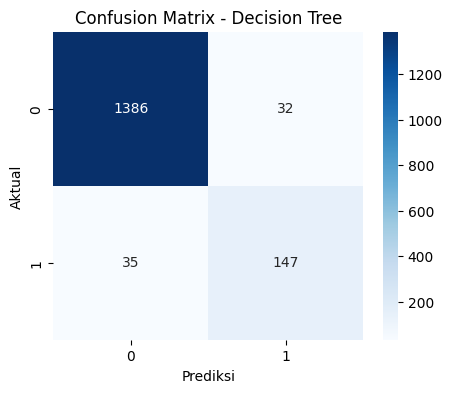

In [24]:
# Visualisasi confusion matrix Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()


In [25]:
# Evaluasi KNN
hasil_knn = evaluasi_model('KNN', y_test, y_pred_knn)


Model: KNN
Accuracy : 0.9113
Precision: 0.7326
Recall   : 0.3462
F1-score : 0.4701
Confusion Matrix:
[[1395   23]
 [ 119   63]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      1418
           1       0.73      0.35      0.47       182

    accuracy                           0.91      1600
   macro avg       0.83      0.66      0.71      1600
weighted avg       0.90      0.91      0.90      1600



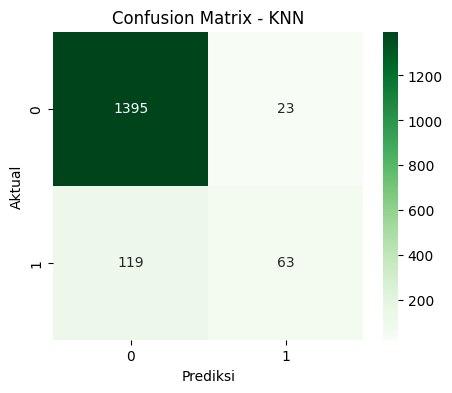

In [26]:
# Visualisasi confusion matrix KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - KNN')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()


In [27]:
# Tabel perbandingan hasil model
hasil = pd.DataFrame([hasil_dt, hasil_knn])
hasil

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.958125,0.821229,0.807692,0.814404
1,KNN,0.911250,0.732558,0.346154,0.470149


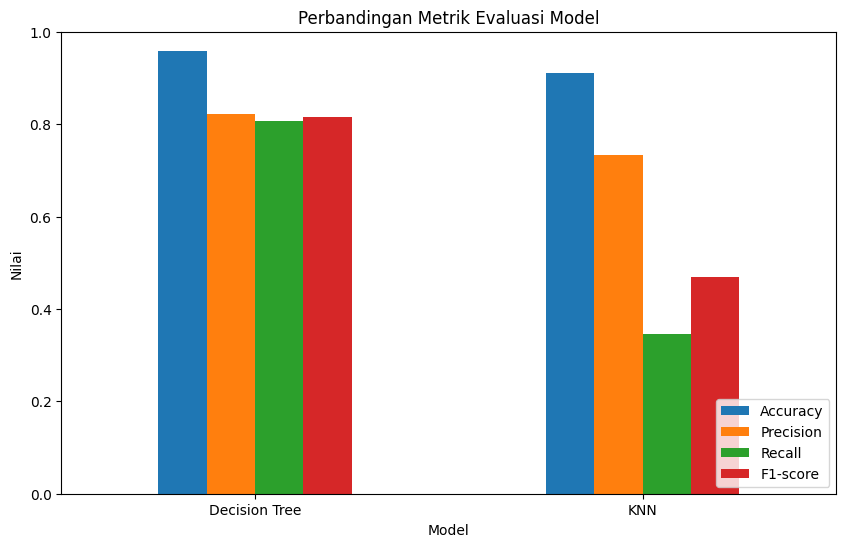

In [28]:
# Visualisasi perbandingan metrik
hasil_plot = hasil.set_index('Model')
hasil_plot.plot(kind='bar', figsize=(10, 6))
plt.title('Perbandingan Metrik Evaluasi Model')
plt.ylabel('Nilai')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

## 9. Feature Importance Decision Tree


In [29]:
# Menampilkan feature importance dari Decision Tree
feature_importance = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': model_dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

,Fitur,Importance
0,aluminium,0.225538
15,perchlorate,0.167972
4,cadmium,0.163594
1,ammonia,0.063712
5,chloramine,0.056676
18,silver,0.054010
16,radium,0.050894
12,nitrates,0.045151
17,selenium,0.027445
9,bacteria,0.026144


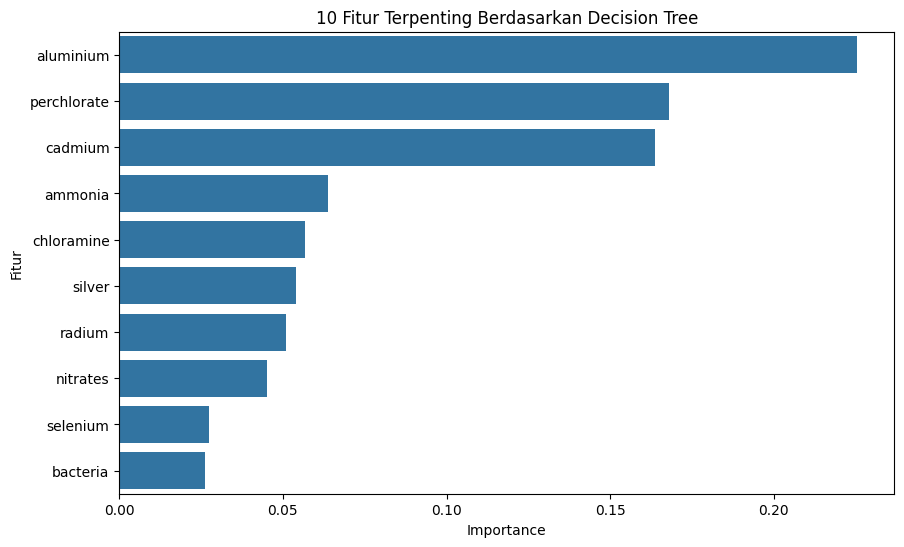

In [30]:
# Visualisasi 10 fitur terpenting
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='Importance', y='Fitur')
plt.title('10 Fitur Terpenting Berdasarkan Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Fitur')
plt.show()


## 10. Visualisasi Pohon Keputusan

Visualisasi pohon dibatasi kedalamannya agar tetap mudah dibaca.


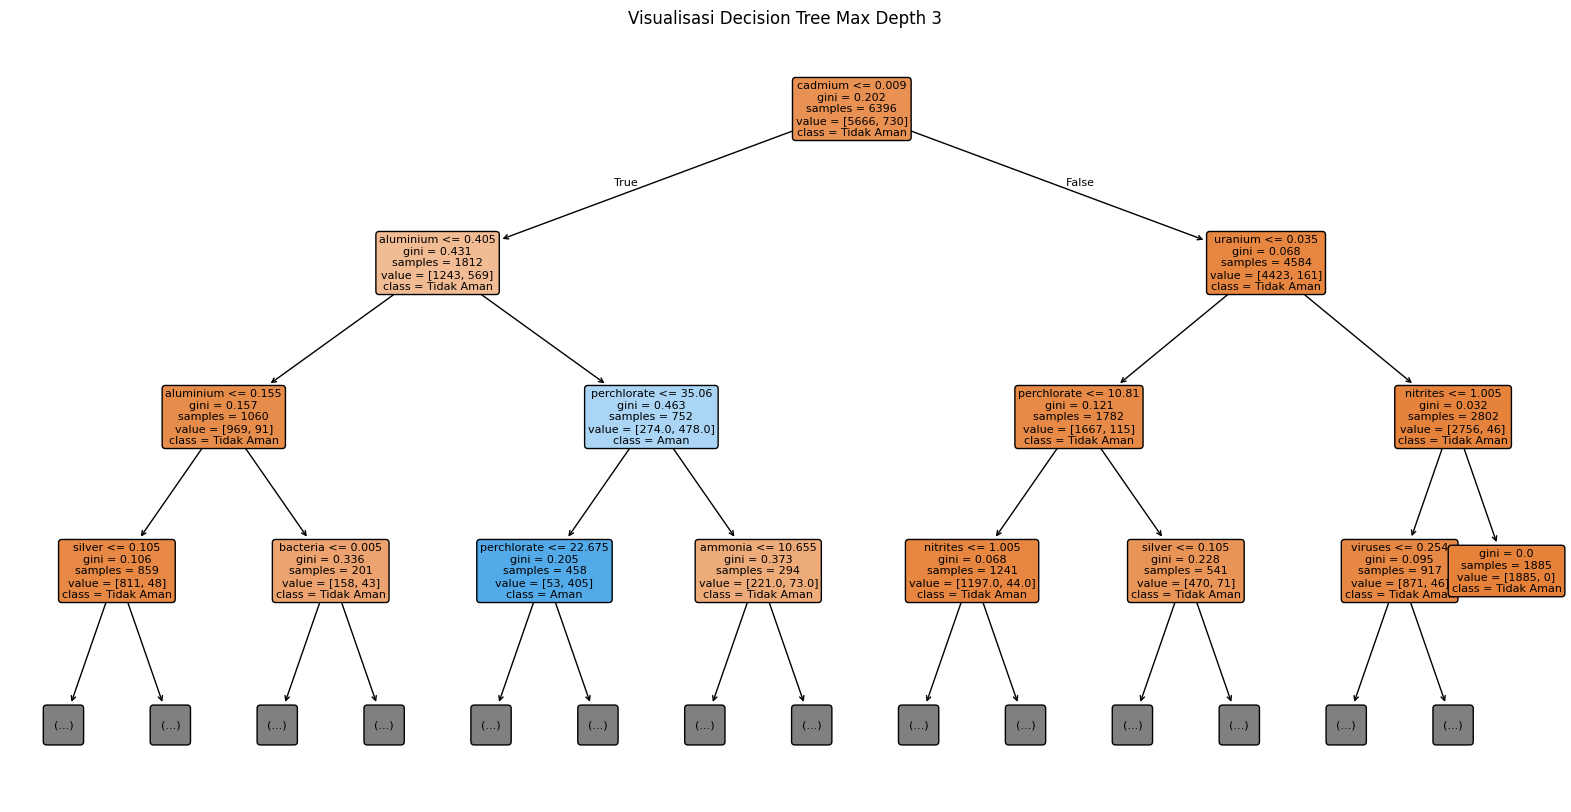

In [31]:
plt.figure(figsize=(20, 10))
plot_tree(
    model_dt,
    feature_names=X.columns,
    class_names=['Tidak Aman', 'Aman'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title('Visualisasi Decision Tree Max Depth 3')
plt.show()


## 11. Kesimpulan

Berdasarkan hasil evaluasi, model Decision Tree memiliki performa terbaik dibandingkan KNN. Decision Tree memperoleh nilai accuracy, precision, recall, dan F1-score yang lebih tinggi. Oleh karena itu, Decision Tree dipilih sebagai model terbaik untuk klasifikasi kualitas air pada dataset ini.

Keterbatasan proyek ini adalah dataset memiliki ketidakseimbangan kelas, sehingga pengembangan selanjutnya dapat mencoba metode penanganan imbalance seperti SMOTE, class weight, serta algoritma lain seperti Random Forest, SVM, XGBoost, atau CatBoost.
